In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import statistics

In [4]:
data = pd.read_csv('NP15_rt_series.csv')
data['begin_time'] = pd.to_datetime(data['begin_time'])
data_15min = data[data['begin_time'].apply(lambda x : x.minute%15 == 0)].reset_index(drop=True)
data_15min

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price
0,2021-01-01 00:00:00,30.76070,NaN,NaN
1,2021-01-01 00:15:00,31.35044,NaN,NaN
2,2021-01-01 00:30:00,32.45147,NaN,NaN
3,2021-01-01 00:45:00,29.98897,NaN,NaN
4,2021-01-01 01:00:00,29.89887,NaN,NaN
...,...,...,...,...
140251,2024-12-31 22:45:00,45.92347,6.20218,39.72129
140252,2024-12-31 23:00:00,46.50217,8.26084,38.24133
140253,2024-12-31 23:15:00,46.25834,7.86632,38.39202
140254,2024-12-31 23:30:00,45.51538,9.08338,36.43200


In [5]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

In [6]:
data_train=data_15min.iloc[:112204]
data_train

,begin_time,NP-15 LMP,NP-15 LMP 24hrdiffs,NP-15 LMP Prev_day_price
0,2021-01-01 00:00:00,30.76070,NaN,NaN
1,2021-01-01 00:15:00,31.35044,NaN,NaN
2,2021-01-01 00:30:00,32.45147,NaN,NaN
3,2021-01-01 00:45:00,29.98897,NaN,NaN
4,2021-01-01 01:00:00,29.89887,NaN,NaN
...,...,...,...,...
112199,2024-03-14 17:45:00,30.46712,4.35904,26.10808
112200,2024-03-14 18:00:00,30.09395,9.17368,20.92027
112201,2024-03-14 18:15:00,30.30745,-1.41394,31.72139
112202,2024-03-14 18:30:00,41.39781,4.69035,36.70746


In [49]:
def crossValidateFinal(year, n_splits, test_size, seas_order, non_seas_order):
    ts_split = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    mse_list = []
    mse_base_list = []

    print(f"Seasonal order - {seas_order}, Non-seasonal order - {non_seas_order}")


    for tod in range(0,2):
      for j in range(3,13, 3):
          time1 = datetime.datetime(year, j, 1, 0, 0, 0)
          time2 = datetime.datetime(year, j, 28, (12 + (6*tod)), 0, 0)
          df = data_train[filter_times(data_train, time1, time2)].reset_index(drop=True)
          for i, (train_index, test_index) in enumerate(ts_split.split(df)):
              model = SARIMAX(endog=df['NP-15 LMP'].loc[train_index], order=non_seas_order, seasonal_order=seas_order)
              model_fit = model.fit()
              forecast = model_fit.forecast(test_size).to_frame(name='predicted')
              eval_df = pd.merge(df[['NP-15 LMP', 'NP-15 LMP Prev_day_price']].loc[test_index], forecast, left_index=True, right_index=True, how='inner')
              #eval_df = eval_df[eval_df.apply(lambda x: (x['NP-15 LMP'].isna()==False) and (x['NP-15 LMP Prev_day_price'].isna()==False))]
              eval_df = eval_df[(eval_df['NP-15 LMP'].isna()==False)]
              eval_df = eval_df[(eval_df['NP-15 LMP Prev_day_price'].isna()==False)]
              if eval_df.empty == False:
                  mse = mean_squared_error(eval_df['NP-15 LMP'], eval_df['predicted'])
                  mse_base = mean_squared_error(eval_df['NP-15 LMP'], eval_df['NP-15 LMP Prev_day_price'])
                  mse_list.append(mse)
                  mse_base_list.append(mse_base)
                  #print(f"mse for validation from time {df['begin_time'].loc[test_index[0]]} to {df['begin_time'].loc[test_index[-1]]} , fold {i} = {mse}. Baseline = {mse_base}")
              #print(model_fit.summary())
              #data_predicted = df.join(pd.concat([df['NP-15 LMP'].loc[train_index].tail(test_size), model_fit.forecast(test_size)]).to_frame(name='predicted'), how='inner')
              #plt.figure(figsize=(18, 4))
              #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP Prev_day_price'] , label='Previous day price')
              #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP'] , label='Actual price')
              #plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')
              #plt.xticks(rotation=90)
              #plt.legend()
              #plt.show()
      print(f" Year {year}, tod {tod} done.")

    print(f"Validation error = {statistics.fmean(mse_list)}, baseline = {statistics.fmean(mse_base_list)}")

In [50]:
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (0,0,0))
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (0,1,0))
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (1,0,0))
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (1,1,0))



Seasonal order - (0, 1, 0, 96), Non-seasonal order - (0, 0, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 2007.4000075839724, baseline = 2007.4000075839724
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (0, 1, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 432.5731775560193, baseline = 2007.4000075839724
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 0, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 611.8337946707455, baseline = 2007.4000075839724
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 1, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 427.3712353734193, baseline = 2007.4000075839724
Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 1, 1)


ValueError: Cannot have number of folds=4 greater than the number of samples=0.

In [51]:
crossValidateFinal(2023, 3, 8, (0,1,0, 96), (1,1,1))

Seasonal order - (0, 1, 0, 96), Non-seasonal order - (1, 1, 1)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 481.63217300957575, baseline = 2007.4000075839724


In [52]:
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (0,0,0))
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (0,1,0))


Seasonal order - (1, 1, 0, 96), Non-seasonal order - (0, 0, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 2162.46089044028, baseline = 2007.4000075839724
Seasonal order - (1, 1, 0, 96), Non-seasonal order - (0, 1, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 342.14228463182076, baseline = 2007.4000075839724


In [54]:
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (1,0,0))
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (1,1,0))


Seasonal order - (1, 1, 0, 96), Non-seasonal order - (1, 0, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 524.1546421151714, baseline = 2007.4000075839724
Seasonal order - (1, 1, 0, 96), Non-seasonal order - (1, 1, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 335.5008400768097, baseline = 2007.4000075839724


In [56]:
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (1,1,1))

Seasonal order - (1, 1, 0, 96), Non-seasonal order - (1, 1, 1)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 340.02746021562285, baseline = 2007.4000075839724


In [68]:
crossValidateFinal(2023, 3, 8, (1,1,0, 96), (2,1,0))

Seasonal order - (1, 1, 0, 96), Non-seasonal order - (2, 1, 0)
 Year 2023, tod 0 done.
 Year 2023, tod 1 done.
Validation error = 331.9744729589341, baseline = 2007.4000075839724


In [1]:
def LastKnownBaseLine(year, n_splits, test_size):
    ts_split = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    mse_list = []
    mse_base_list = []

    for tod in range(0,2):
      for j in range(3,13, 3):
          time1 = datetime.datetime(year, j, 1, 0, 0, 0)
          time2 = datetime.datetime(year, j, 28, (12 + (6*tod)), 0, 0)
          df = data_train[filter_times(data_train, time1, time2)].reset_index(drop=True)
          for i, (train_index, test_index) in enumerate(ts_split.split(df)):
              forecast = pd.DataFrame([df['NP-15 LMP'].iloc[train_index[-1]]]*len(test_index), index=test_index, columns=['predicted'])
              eval_df = pd.merge(df[['NP-15 LMP', 'NP-15 LMP Prev_day_price']].loc[test_index], forecast, left_index=True, right_index=True, how='inner')
              eval_df = eval_df[(eval_df['NP-15 LMP'].isna()==False)]
              eval_df = eval_df[(eval_df['NP-15 LMP Prev_day_price'].isna()==False)]
              if eval_df.empty == False:
                  mse = mean_squared_error(eval_df['NP-15 LMP'], eval_df['predicted'])
                  mse_base = mean_squared_error(eval_df['NP-15 LMP'], eval_df['NP-15 LMP Prev_day_price'])
                  mse_base_list.append(mse_base)
                  mse_list.append(mse)
                  print(f"mse for validation from time {df['begin_time'].loc[test_index[0]]} to {df['begin_time'].loc[test_index[-1]]} , fold {i} = {mse}. Baseline = {mse_base}")
              data_predicted = df.join(pd.concat([df['NP-15 LMP'].loc[train_index].tail(test_size), pd.Series([df['NP-15 LMP'].iloc[train_index[-1]]]*len(test_index), index=test_index)]).to_frame(name='predicted'), how='inner')
              plt.figure(figsize=(18, 4))
              #plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP Prev_day_price'] , label='Previous day price')
              plt.plot(data_predicted['begin_time'], data_predicted['NP-15 LMP'] , label='Actual price')
              plt.plot(data_predicted['begin_time'], data_predicted['predicted'] , label='Predicted')
              plt.xticks(rotation=90)
              plt.legend()
              plt.show()
      print(f" Year {year}, tod {tod} done.")

    print(f"Validation error = {statistics.fmean(mse_list)}, baseline = {statistics.fmean(mse_base_list)}")

mse for validation from time 2023-03-28 06:15:00 to 2023-03-28 08:00:00 , fold 0 = 532.3490378779125. Baseline = 444.72184722942524


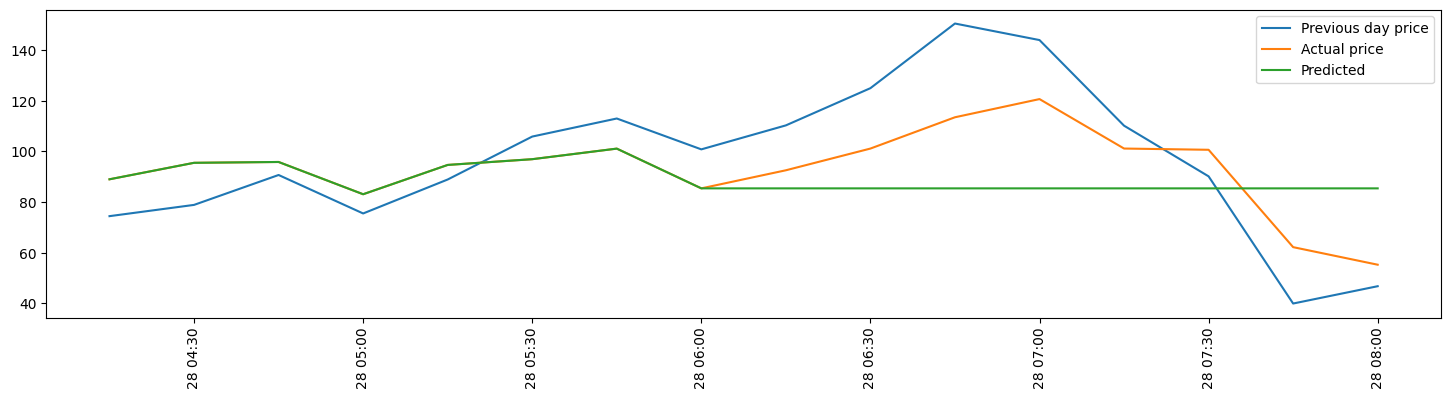

mse for validation from time 2023-03-28 08:15:00 to 2023-03-28 10:00:00 , fold 1 = 1787.18264192805. Baseline = 7229.777767236337


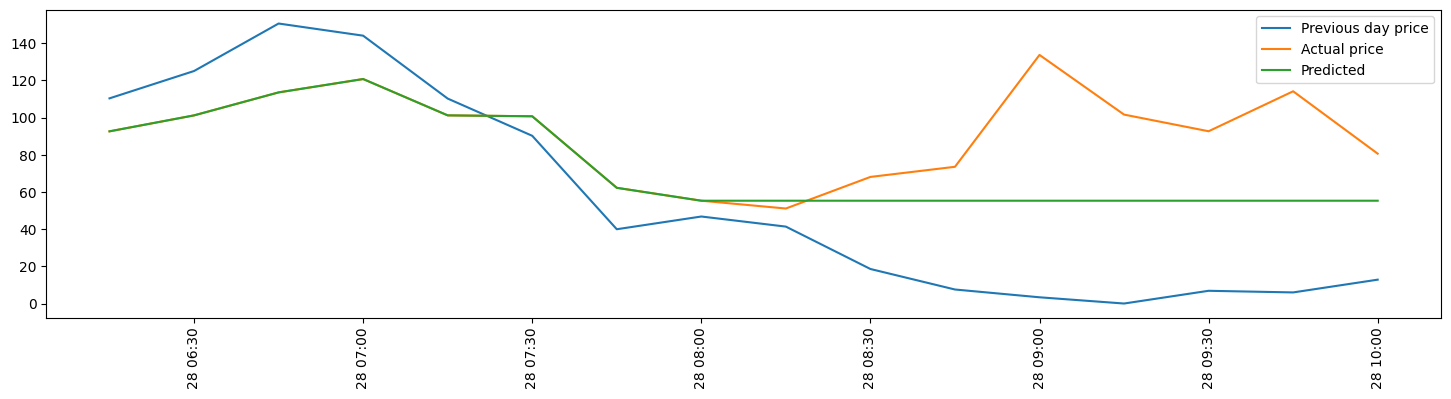

mse for validation from time 2023-03-28 10:15:00 to 2023-03-28 12:00:00 , fold 2 = 257.07195506503746. Baseline = 6614.916175442264


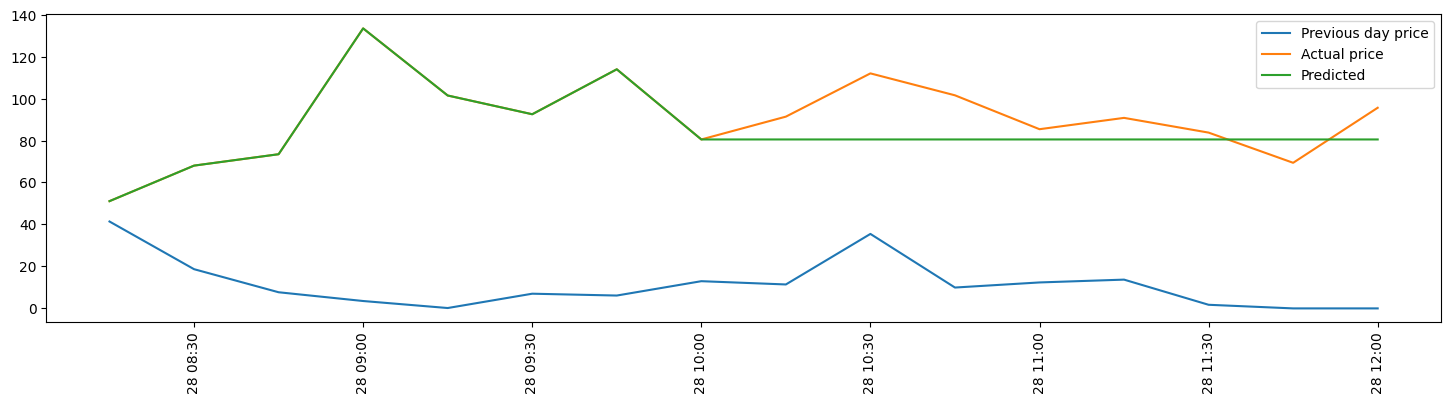

mse for validation from time 2023-06-28 06:15:00 to 2023-06-28 08:00:00 , fold 0 = 136.54733867027505. Baseline = 68.01915942499998


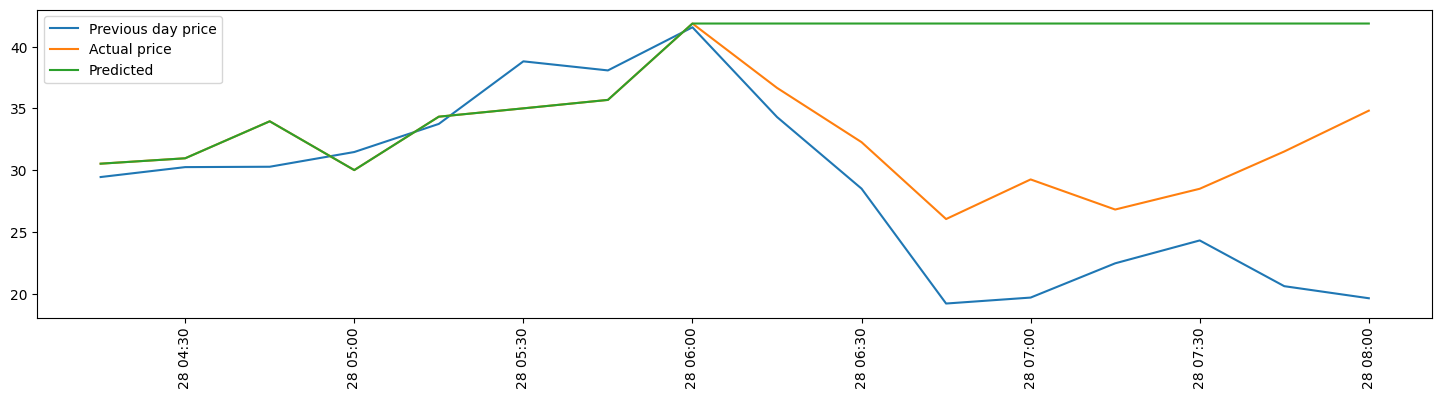

mse for validation from time 2023-06-28 08:15:00 to 2023-06-28 10:00:00 , fold 1 = 3.7374673638374905. Baseline = 265.913235958175


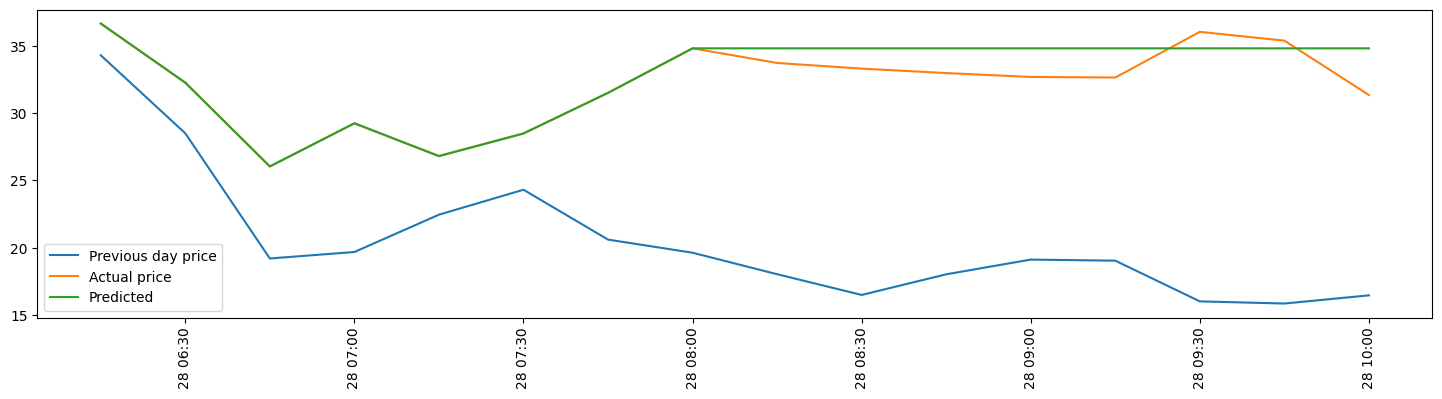

mse for validation from time 2023-06-28 10:15:00 to 2023-06-28 12:00:00 , fold 2 = 1.4839320621250018. Baseline = 149.5370629491875


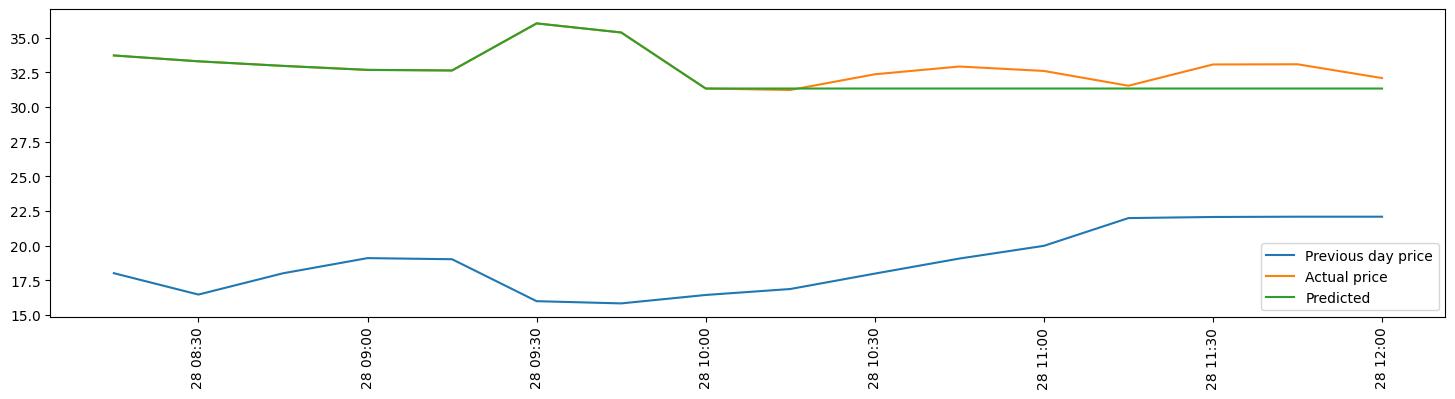

mse for validation from time 2023-09-28 06:15:00 to 2023-09-28 08:00:00 , fold 0 = 280.554677111175. Baseline = 319.45975391878744


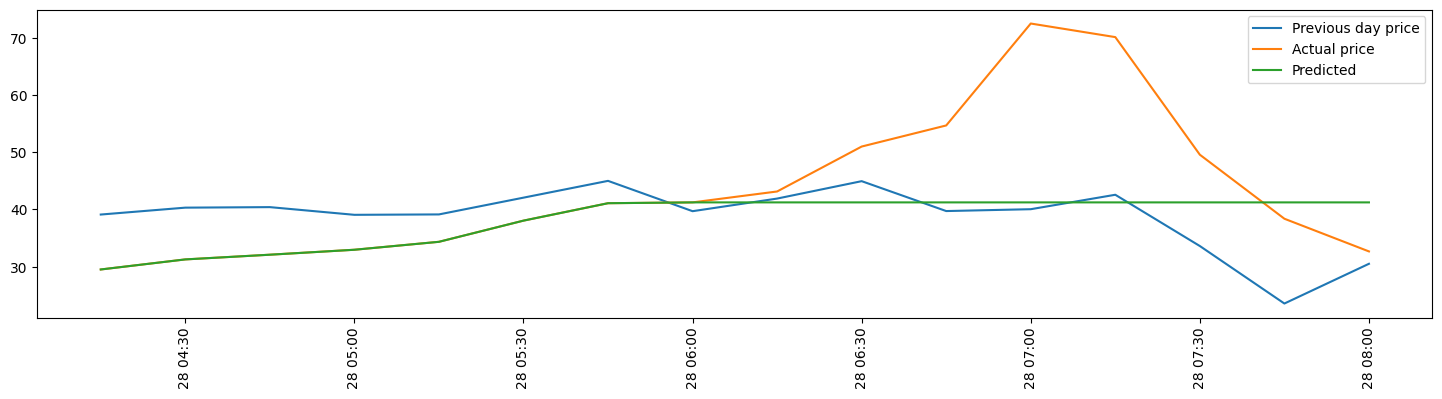

mse for validation from time 2023-09-28 08:15:00 to 2023-09-28 10:00:00 , fold 1 = 3.9369025350374978. Baseline = 349.07077921879994


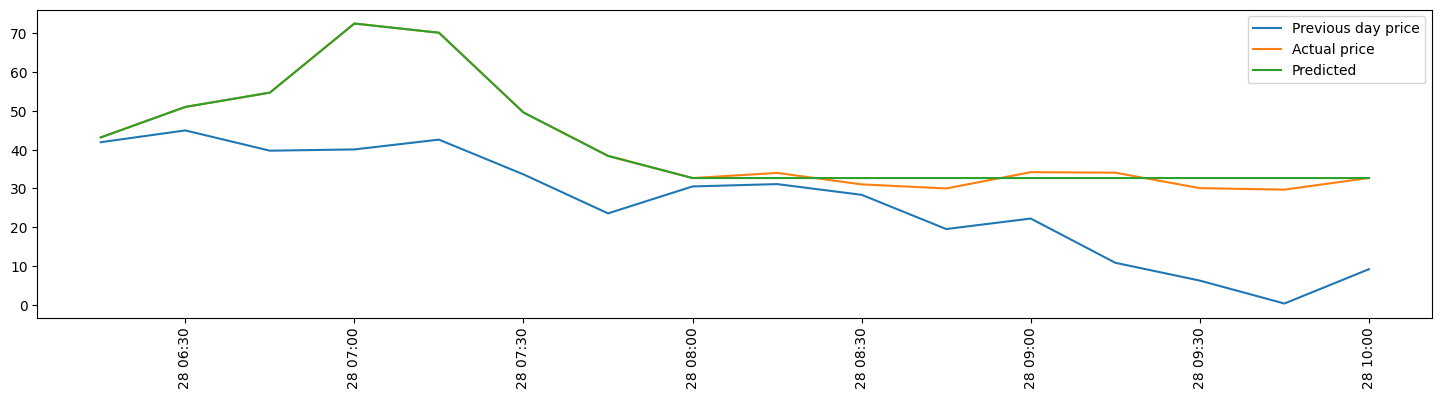

mse for validation from time 2023-09-28 10:15:00 to 2023-09-28 12:00:00 , fold 2 = 4.633729127562502. Baseline = 546.9582111801626


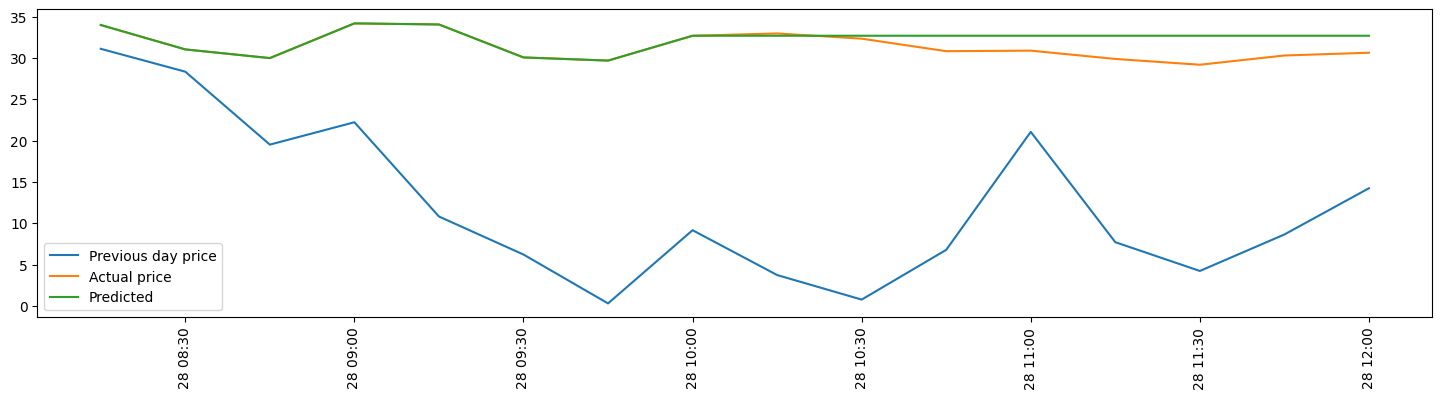

mse for validation from time 2023-12-28 06:15:00 to 2023-12-28 08:00:00 , fold 0 = 86.31213470354997. Baseline = 127.91749402295


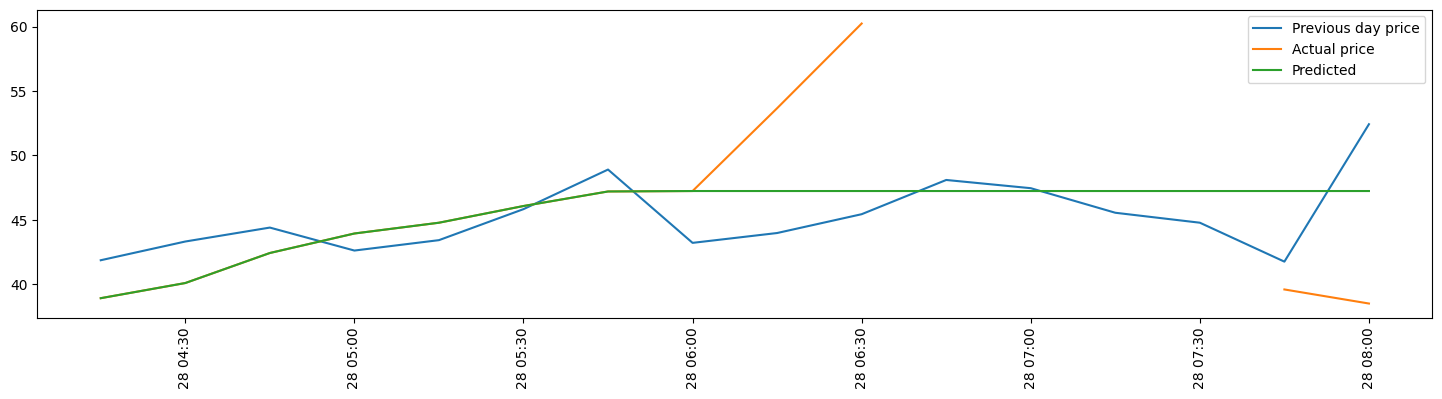

mse for validation from time 2023-12-28 08:15:00 to 2023-12-28 10:00:00 , fold 1 = 150.1935375719625. Baseline = 234.6227843004375


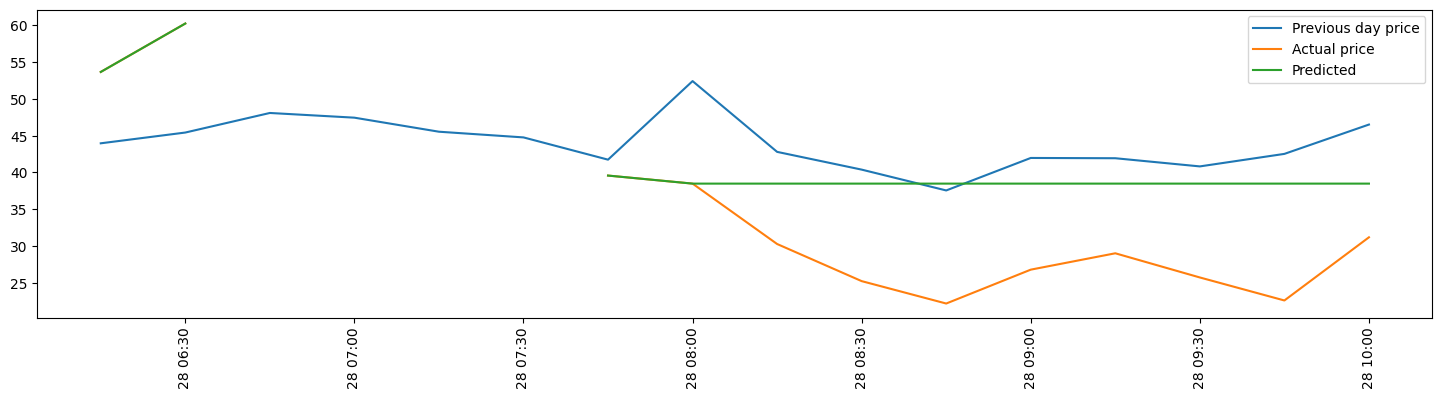

mse for validation from time 2023-12-28 10:15:00 to 2023-12-28 12:00:00 , fold 2 = 24.34857164145001. Baseline = 53.3169968204


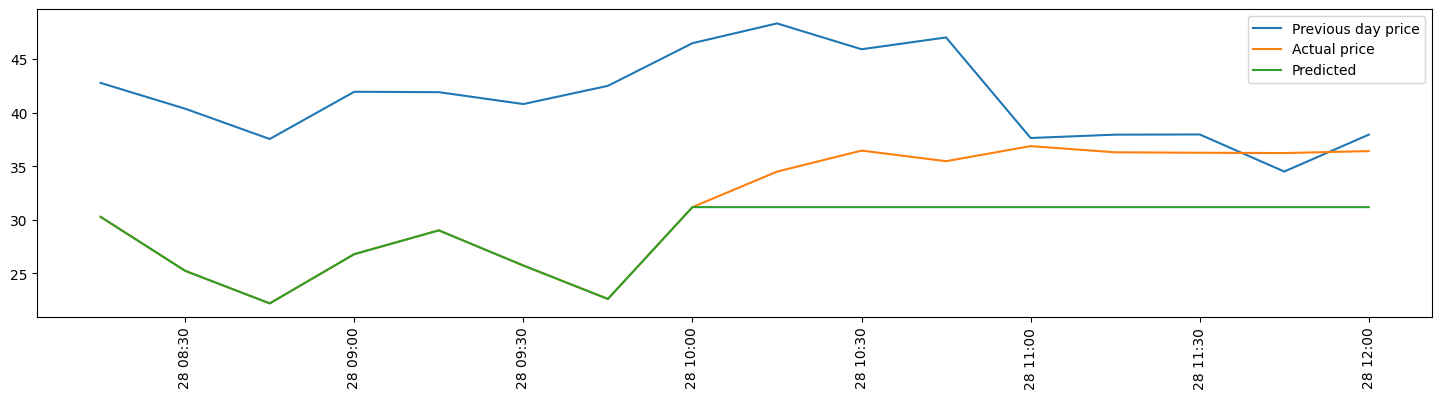

 Year 2023, tod 0 done.
mse for validation from time 2023-03-28 12:15:00 to 2023-03-28 14:00:00 , fold 0 = 113.88093755744997. Baseline = 12287.02185822375


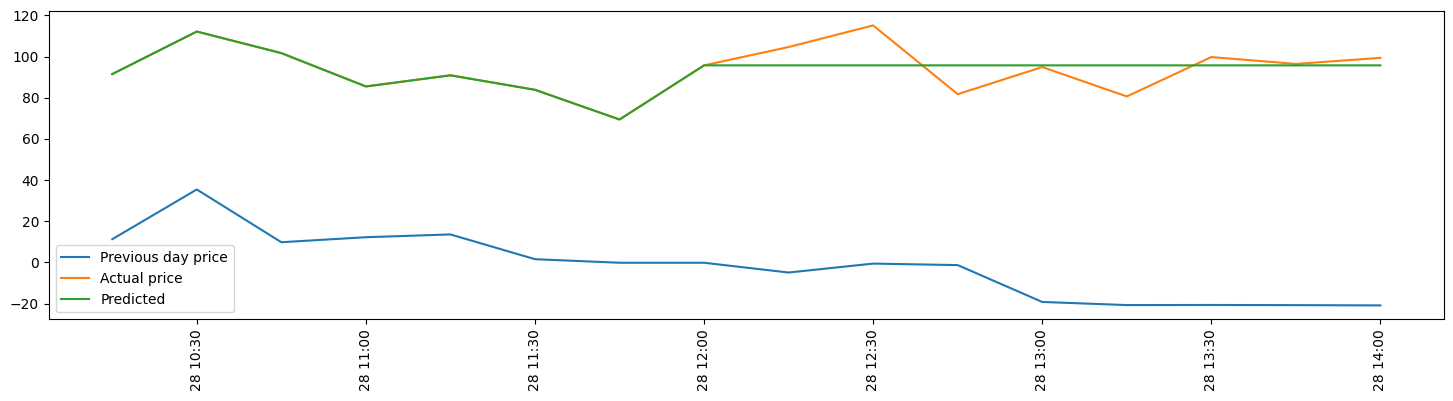

mse for validation from time 2023-03-28 14:15:00 to 2023-03-28 16:00:00 , fold 1 = 100.84268140640006. Baseline = 12459.53417853675


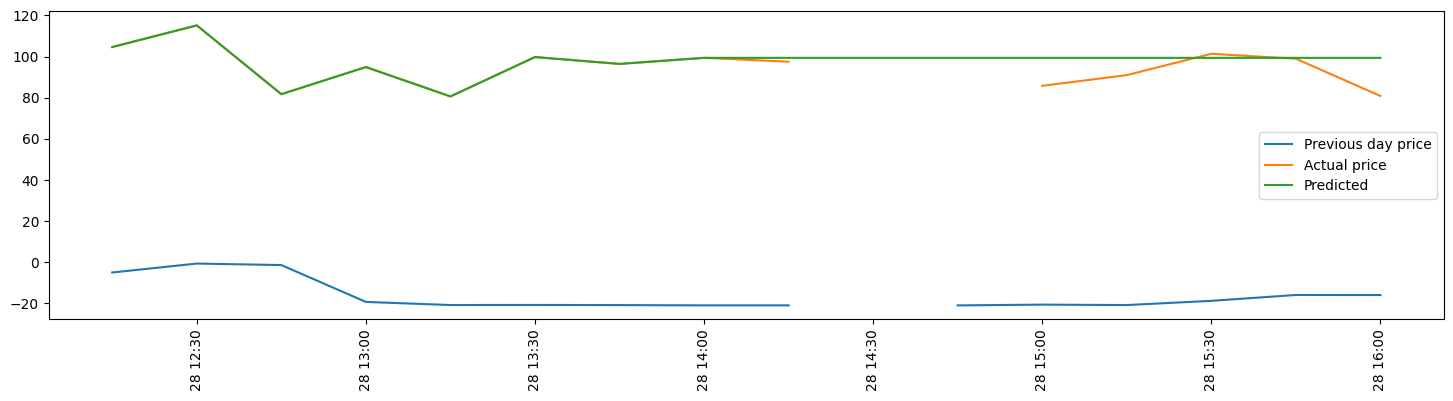

mse for validation from time 2023-03-28 16:15:00 to 2023-03-28 18:00:00 , fold 2 = 358.5956644372625. Baseline = 6393.15968889985


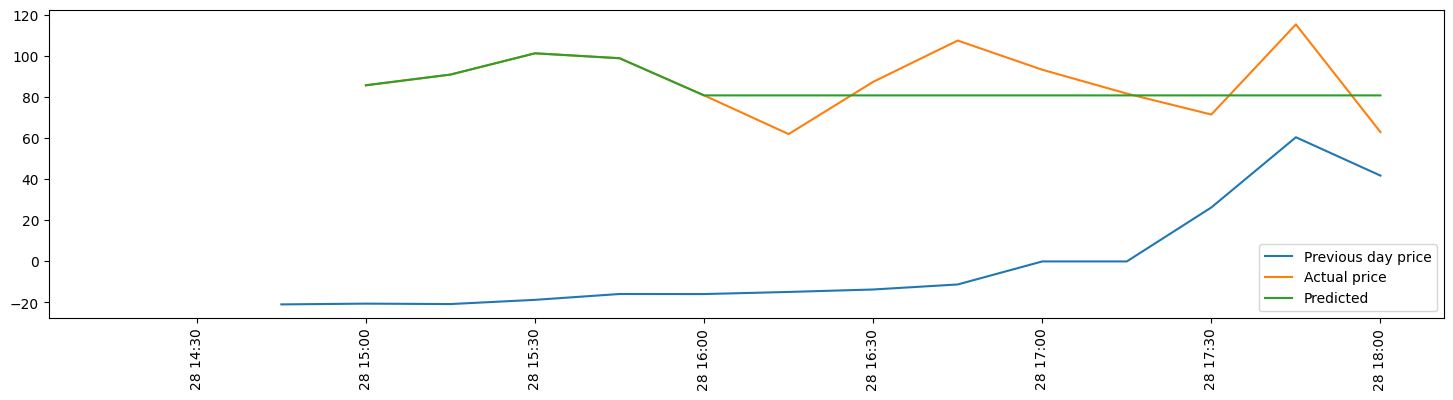

mse for validation from time 2023-06-28 12:15:00 to 2023-06-28 14:00:00 , fold 0 = 15.373250540725. Baseline = 95.71905776496249


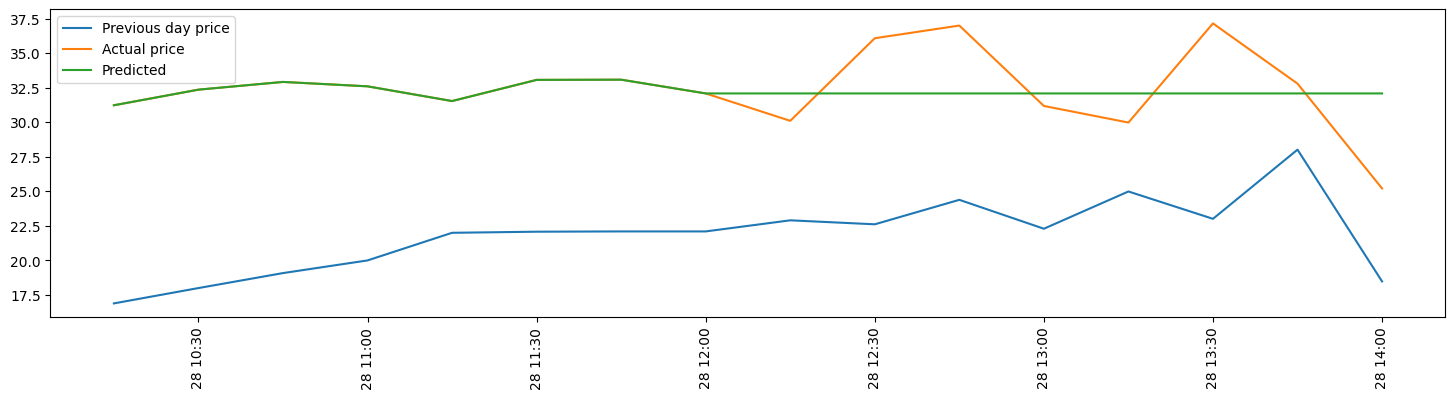

mse for validation from time 2023-06-28 14:15:00 to 2023-06-28 16:00:00 , fold 1 = 44.48681263202499. Baseline = 43.27856813191249


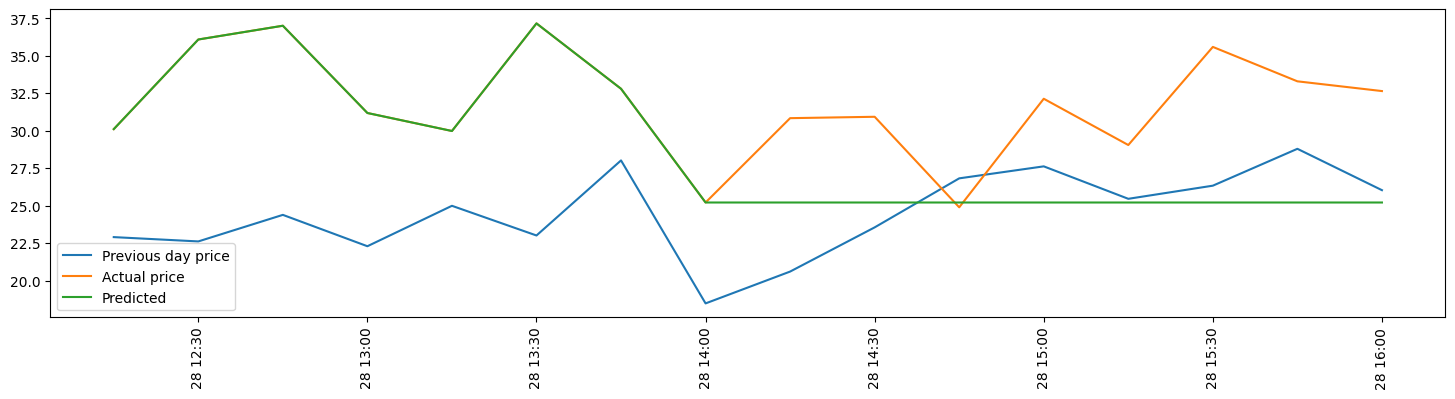

mse for validation from time 2023-06-28 16:15:00 to 2023-06-28 18:00:00 , fold 2 = 37.760399439775014. Baseline = 28.103024027775


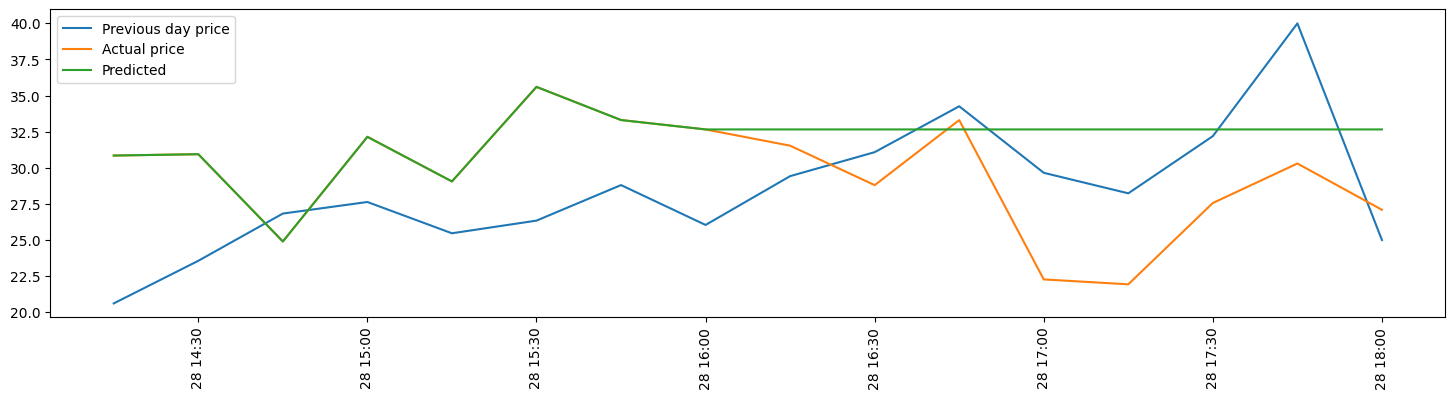

mse for validation from time 2023-09-28 12:15:00 to 2023-09-28 14:00:00 , fold 0 = 44.14695623228749. Baseline = 58.83490519113748


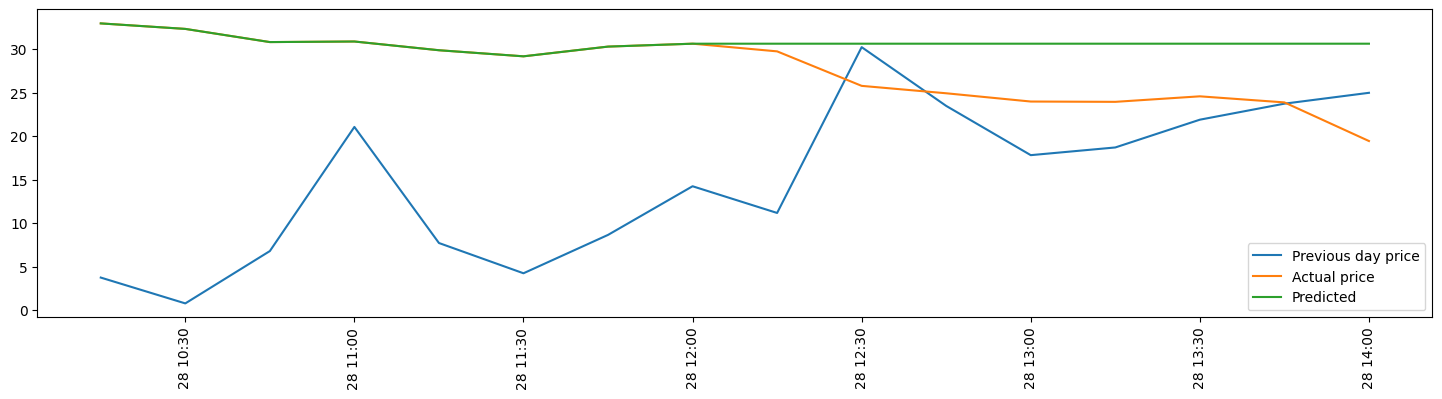

mse for validation from time 2023-09-28 14:15:00 to 2023-09-28 16:00:00 , fold 1 = 73.03533200973749. Baseline = 127.26001269133752


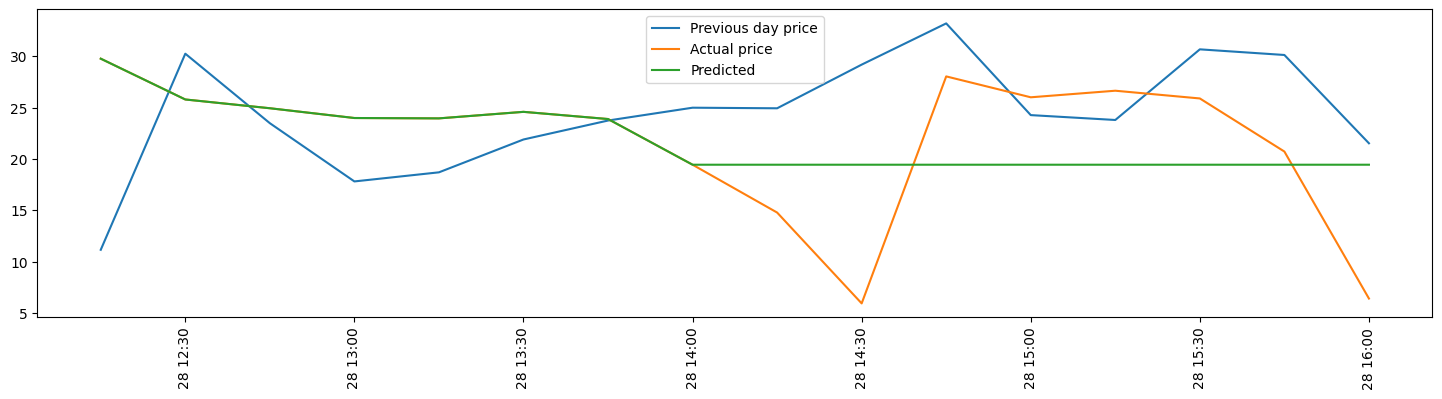

mse for validation from time 2023-09-28 16:15:00 to 2023-09-28 18:00:00 , fold 2 = 543.02049846785. Baseline = 61.45872719911251


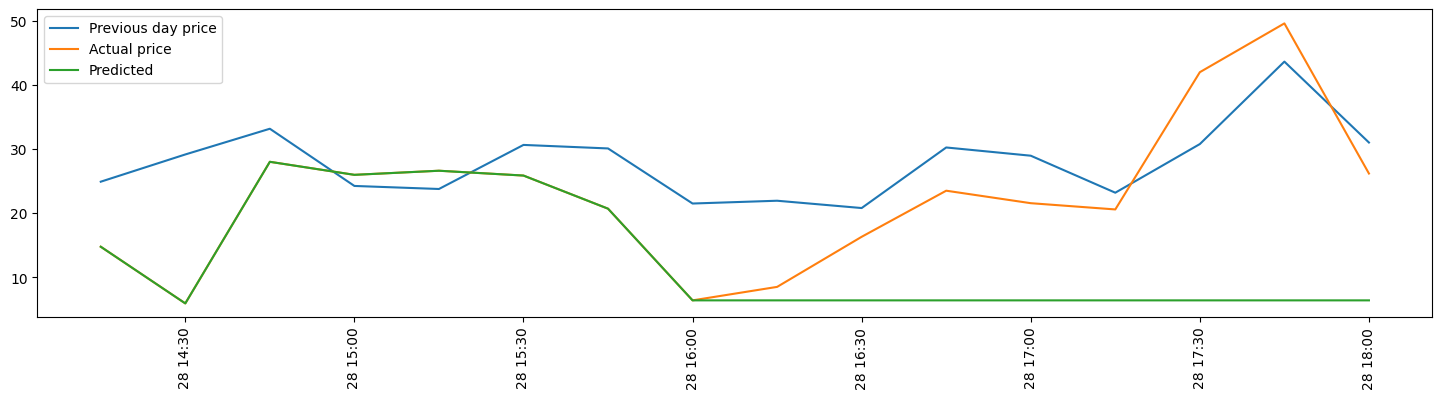

mse for validation from time 2023-12-28 12:15:00 to 2023-12-28 14:00:00 , fold 0 = 2.6832771797750086. Baseline = 21.789523639737503


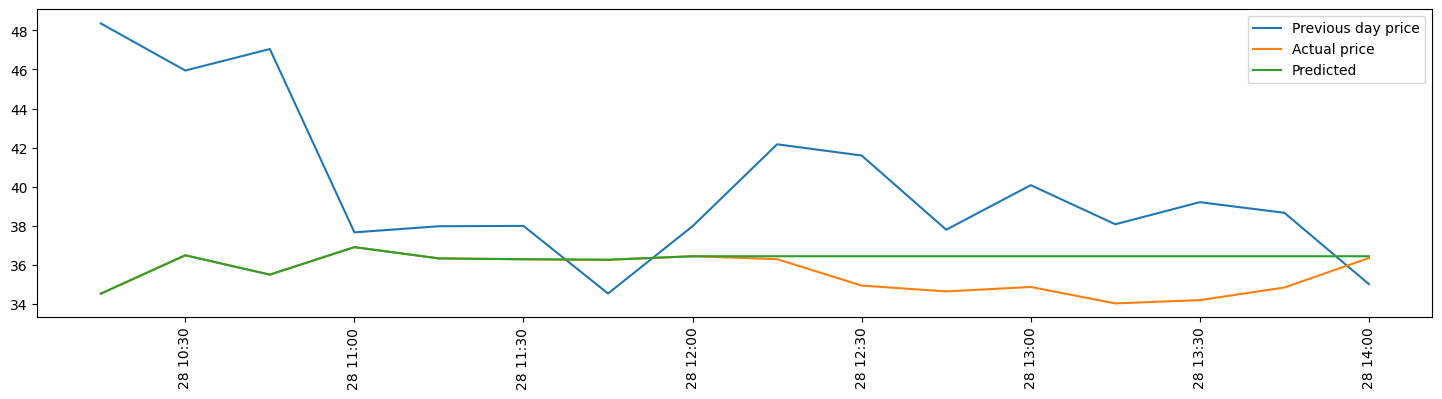

mse for validation from time 2023-12-28 14:15:00 to 2023-12-28 16:00:00 , fold 1 = 68.19703947648748. Baseline = 190.7334373946125


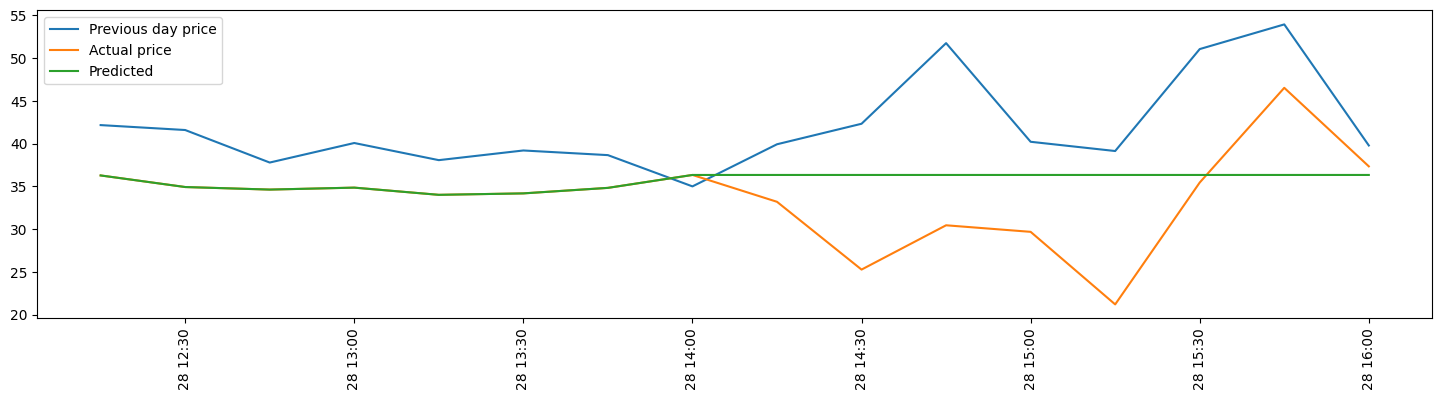

mse for validation from time 2023-12-28 16:15:00 to 2023-12-28 18:00:00 , fold 2 = 106.50615465085001. Baseline = 6.475932612474995


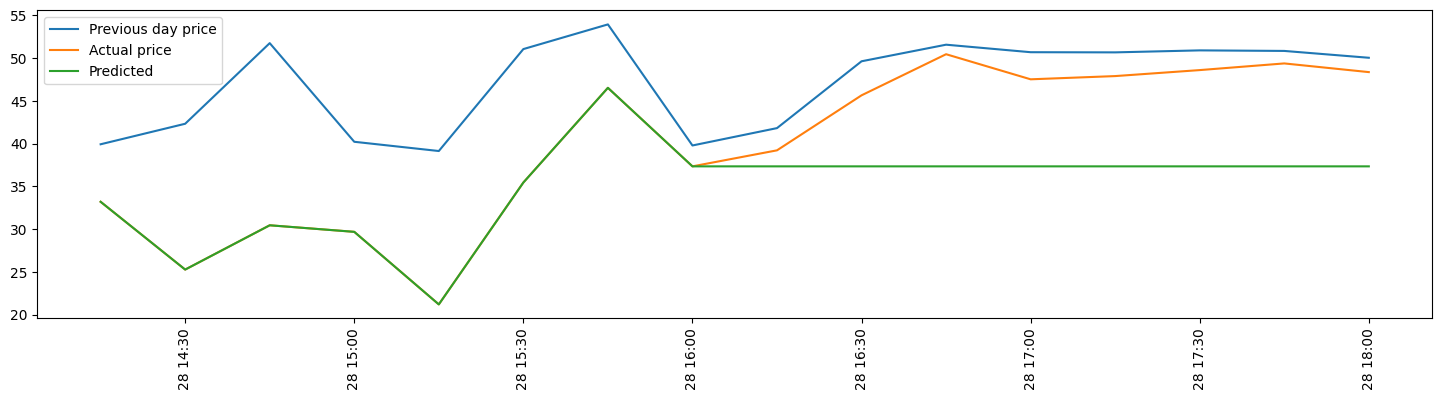

 Year 2023, tod 1 done.
Validation error = 199.03670540369168, baseline = 2007.4000075839724


In [67]:
LastKnownBaseLine(2023, 3, 8)